Số feature: 18
['time_interval_std', 'upload_burst_ratio', 'video_upload_frequency', 'view_per_video', 'dash_density', 'title_length_std', 'capitalization_ratio', 'opening_repeat_ratio', 'temporal_clickbait_ratio', 'type_token_ratio', 'avg_title_similarity', 'sub_to_view_ratio', 'subscriber_velocity', 'sub_to_view_velocity_ratio', 'subscriber_count', 'view_count', 'video_count', 'n_videos_crawled']
Top feature quan trọng nhất:


,feature,importance
14,subscriber_count,0.218904
15,view_count,0.116363
3,view_per_video,0.113521
10,avg_title_similarity,0.075206
0,time_interval_std,0.064151
12,subscriber_velocity,0.064033
2,video_upload_frequency,0.051940
16,video_count,0.050179
5,title_length_std,0.048677
9,type_token_ratio,0.031187


Top 6 features: ['subscriber_count', 'view_count', 'view_per_video', 'avg_title_similarity', 'time_interval_std', 'subscriber_velocity']


C:\Users\DELL\AppData\Local\Temp\ipykernel_29128\2244656577.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


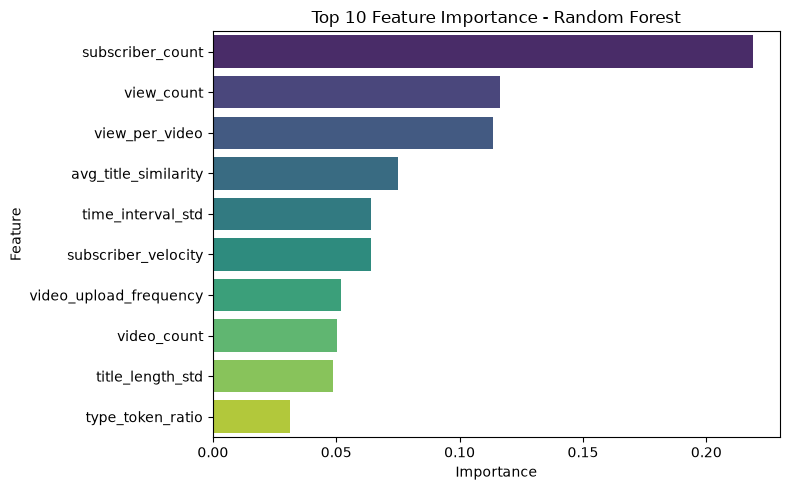

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

file_path = "../data/processed/features_final.csv"
label_col = "label"

fig_dir = Path("../output/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(file_path)


# =========================
# 1. Mã hóa label
# =========================

if df[label_col].dtype == "object":
    df[label_col] = df[label_col].map({
        "genuine": 0,
        "slop": 1
    })


# =========================
# 2. Chuẩn bị dữ liệu model
# =========================

feature_cols = df.drop(columns=[label_col]).select_dtypes(include=[np.number]).columns.tolist()

X = df[feature_cols]
y = df[label_col]

print("Số feature:", len(feature_cols))
print(feature_cols)


# =========================
# 3. Chia tập train/test
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 4. Train Random Forest
# =========================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)


# =========================
# 5. Tính feature importance
# =========================

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("Top feature quan trọng nhất:")
display(importance_df.head(10))

top_features = importance_df.head(6)["feature"].tolist()
print("Top 6 features:", top_features)


# =========================
# 6. Vẽ feature importance
# =========================

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(fig_dir / "02_top10_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

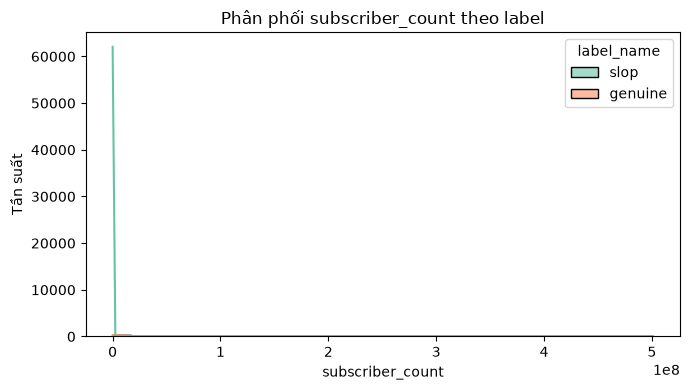

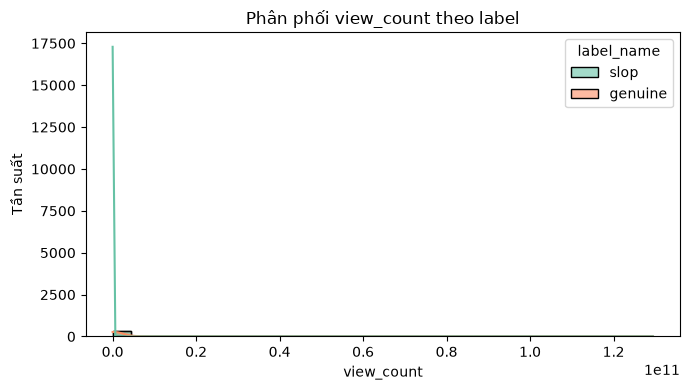

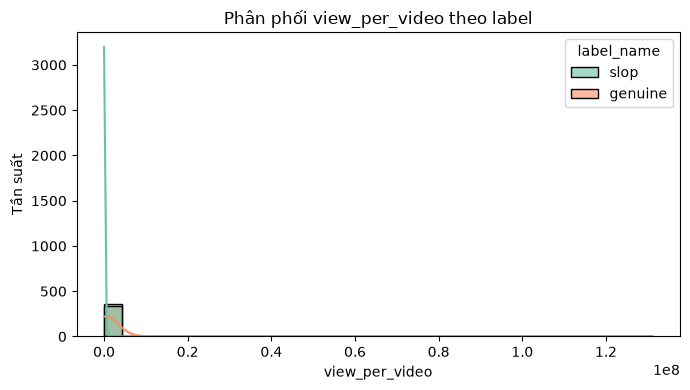

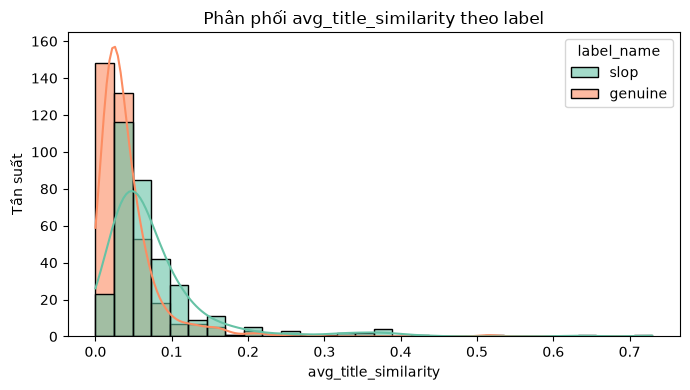

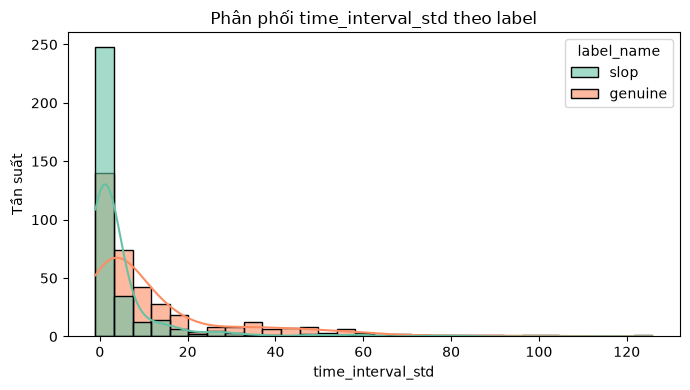

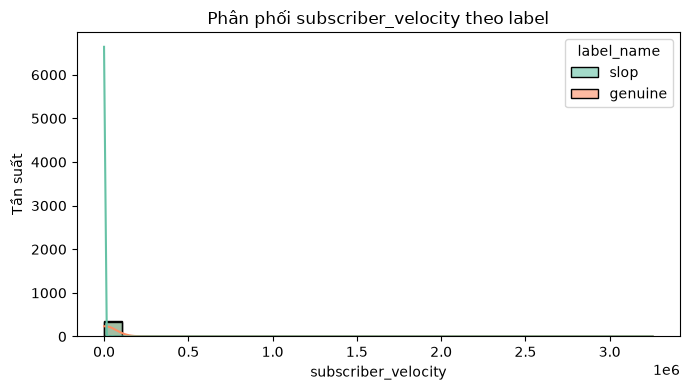

C:\Users\DELL\AppData\Local\Temp\ipykernel_29128\3617252089.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


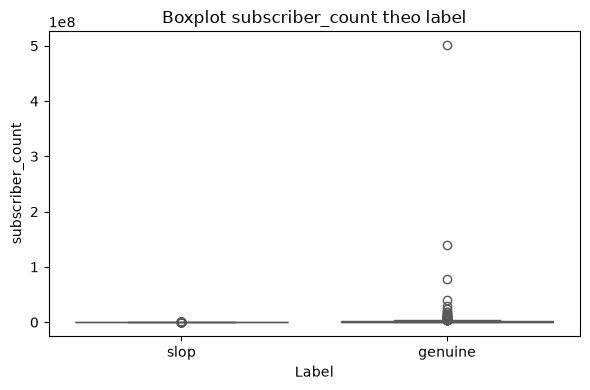

C:\Users\DELL\AppData\Local\Temp\ipykernel_29128\3617252089.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


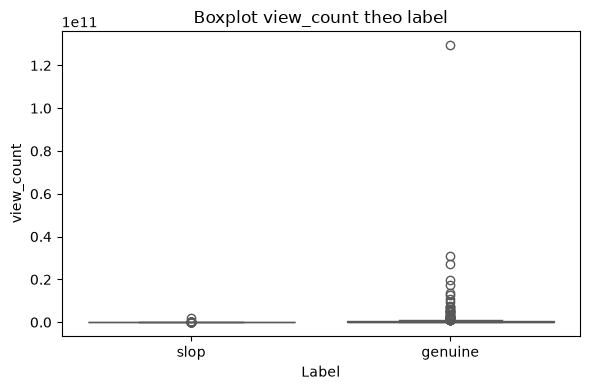

C:\Users\DELL\AppData\Local\Temp\ipykernel_29128\3617252089.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


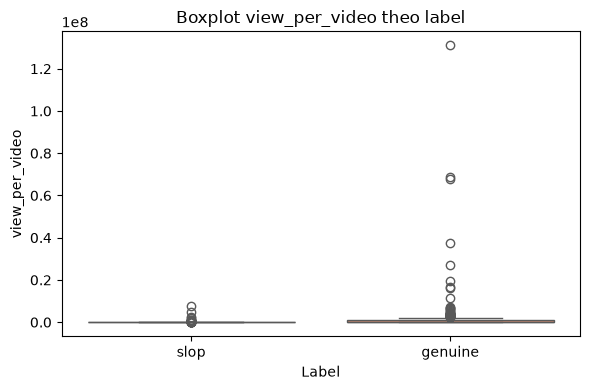

C:\Users\DELL\AppData\Local\Temp\ipykernel_29128\3617252089.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


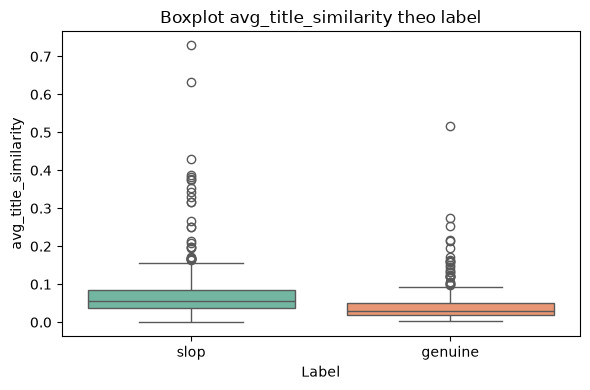

C:\Users\DELL\AppData\Local\Temp\ipykernel_29128\3617252089.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


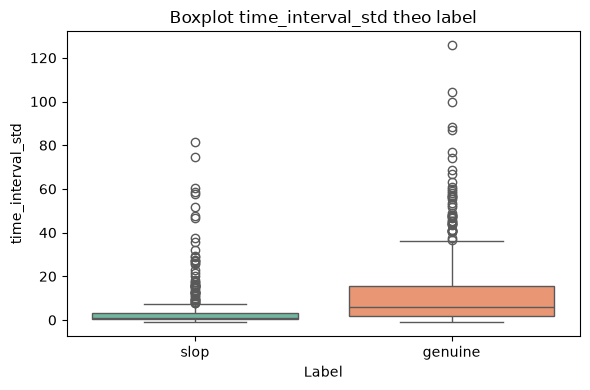

C:\Users\DELL\AppData\Local\Temp\ipykernel_29128\3617252089.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


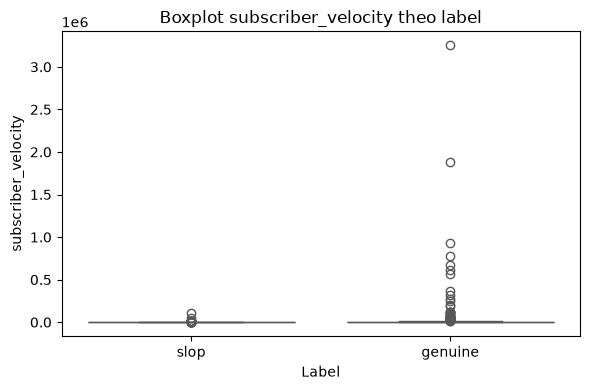

In [ ]:
# =========================
# 7. Tạo label dạng chữ để vẽ biểu đồ
# =========================

plot_df = df.copy()
plot_df["label_name"] = plot_df[label_col].map({
    0: "genuine",
    1: "slop"
})


# =========================
# 8. Vẽ histogram cho top features theo label
# =========================

for col in top_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=plot_df,
        x=col,
        hue="label_name",
        kde=True,
        bins=30,
        palette="Set2",
        alpha=0.6
    )
    plt.title(f"Phân phối {col} theo label")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.tight_layout()
    plt.savefig(fig_dir / f"03_hist_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()


# =========================
# 9. Vẽ boxplot cho top features theo label
# =========================

for col in top_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=plot_df,
        x="label_name",
        y=col,
        palette="Set2"
    )
    plt.title(f"Boxplot {col} theo label")
    plt.xlabel("Label")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(fig_dir / f"04_boxplot_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
# =========================
# 10. Thống kê mô tả top features theo label
# =========================

summary = plot_df.groupby("label_name")[top_features].agg(["mean", "median", "std"])
display(summary)


# =========================
# 11. Nhận xét sự khác biệt giữa hai lớp
# =========================

for col in top_features:
    genuine_mean = plot_df.loc[plot_df["label_name"] == "genuine", col].mean()
    slop_mean = plot_df.loc[plot_df["label_name"] == "slop", col].mean()
    diff = slop_mean - genuine_mean

    print(f"\nFeature: {col}")
    print(f"Mean genuine: {genuine_mean:.4f}")
    print(f"Mean slop:    {slop_mean:.4f}")
    print(f"Chênh lệch slop - genuine: {diff:.4f}")

    if diff > 0:
        print("Nhận xét: feature này có xu hướng cao hơn ở lớp slop.")
    elif diff < 0:
        print("Nhận xét: feature này có xu hướng thấp hơn ở lớp slop.")
    else:
        print("Nhận xét: hai lớp gần như không khác biệt về trung bình.")

subscriber_count                            view_count              \
                       mean    median           std          mean      median   
label_name                                                                      
genuine        3.631758e+06  502000.0  2.720470e+07  1.166594e+09  69461329.0   
slop           3.129453e+04    3280.0  9.403198e+04  1.197291e+07    422847.0   

                         view_per_video                               \
                     std           mean         median           std   
label_name                                                             
genuine     7.236341e+09   1.768113e+06  279533.361364  8.815620e+06   
slop        9.980738e+07   9.918223e+04    6836.919643  5.359893e+05   

           avg_title_similarity                     time_interval_std  \
                           mean    median       std              mean   
label_name                                                              
genuine                0.041915  0.029236  0.044392         13.503349   
slop                   0.077686  0.054590  0.080910          4.861695   

                                subscriber_velocity               \
              median        std                mean       median   
label_name                                                         
genuine     5.976921  18.885821        35326.899603  1126.314921   
slop        1.025989  10.769911         1061.531426    46.224841   

                           
                      std  
label_name                 
genuine     211978.741387  
slop          6466.860899


Feature: subscriber_count
Mean genuine: 3631758.3236
Mean slop:    31294.5313
Chênh lệch slop - genuine: -3600463.7923
Nhận xét: feature này có xu hướng thấp hơn ở lớp slop.

Feature: view_count
Mean genuine: 1166594196.8329
Mean slop:    11972908.5552
Chênh lệch slop - genuine: -1154621288.2777
Nhận xét: feature này có xu hướng thấp hơn ở lớp slop.

Feature: view_per_video
Mean genuine: 1768112.8216
Mean slop:    99182.2316
Chênh lệch slop - genuine: -1668930.5900
Nhận xét: feature này có xu hướng thấp hơn ở lớp slop.

Feature: avg_title_similarity
Mean genuine: 0.0419
Mean slop:    0.0777
Chênh lệch slop - genuine: 0.0358
Nhận xét: feature này có xu hướng cao hơn ở lớp slop.

Feature: time_interval_std
Mean genuine: 13.5033
Mean slop:    4.8617
Chênh lệch slop - genuine: -8.6417
Nhận xét: feature này có xu hướng thấp hơn ở lớp slop.

Feature: subscriber_velocity
Mean genuine: 35326.8996
Mean slop:    1061.5314
Chênh lệch slop - genuine: -34265.3682
Nhận xét: feature này có xu hướng 

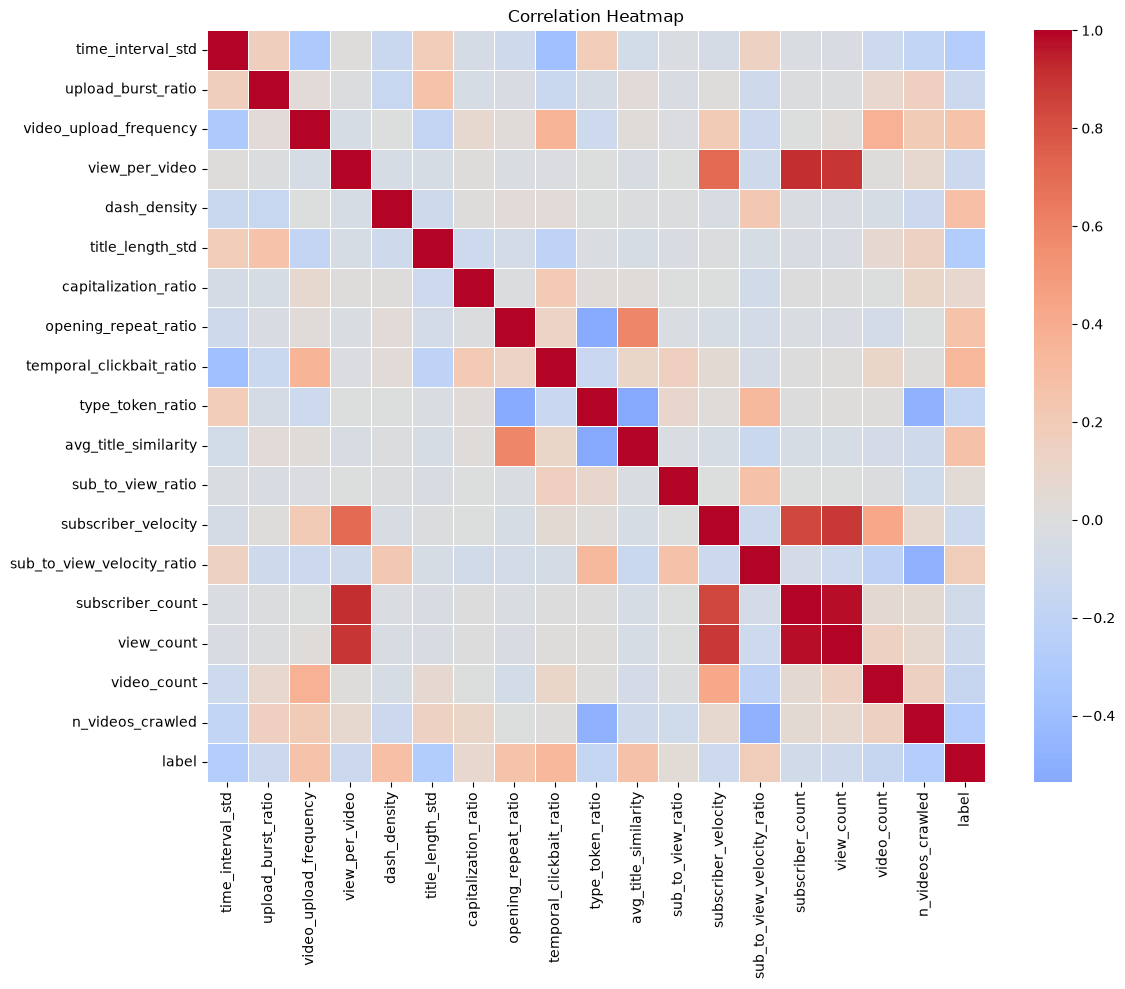

Feature tương quan mạnh nhất với label:


temporal_clickbait_ratio      0.329298
dash_density                  0.283088
title_length_std             -0.279257
avg_title_similarity          0.268238
n_videos_crawled             -0.267391
time_interval_std            -0.266797
opening_repeat_ratio          0.266084
video_upload_frequency        0.257860
sub_to_view_velocity_ratio    0.175792
type_token_ratio             -0.168765
Name: label, dtype: float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_29128\2131491133.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


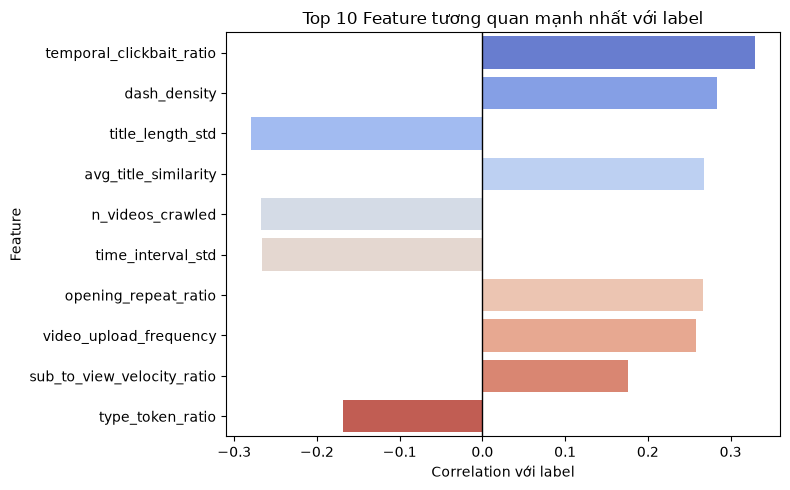

In [ ]:
# =========================
# 12. Tính ma trận tương quan
# =========================

corr_df = df[feature_cols + [label_col]].corr()


# =========================
# 13. Vẽ correlation heatmap
# =========================

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_df,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(fig_dir / "05_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 14. Feature tương quan mạnh nhất với label
# =========================

label_corr = corr_df[label_col].drop(label_col).sort_values(key=abs, ascending=False)

print("Feature tương quan mạnh nhất với label:")
display(label_corr.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(
    x=label_corr.head(10).values,
    y=label_corr.head(10).index,
    palette="coolwarm"
)
plt.title("Top 10 Feature tương quan mạnh nhất với label")
plt.xlabel("Correlation với label")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.savefig(fig_dir / "06_top_label_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# =========================
# 15. Tìm các cặp feature tương quan mạnh
# =========================

threshold = 0.8
corr_features = corr_df.loc[feature_cols, feature_cols]

high_corr_pairs = []

for i in range(len(corr_features.columns)):
    for j in range(i + 1, len(corr_features.columns)):
        corr_value = corr_features.iloc[i, j]

        if abs(corr_value) >= threshold:
            high_corr_pairs.append({
                "feature_1": corr_features.columns[i],
                "feature_2": corr_features.columns[j],
                "correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if len(high_corr_df) > 0:
    high_corr_df = high_corr_df.sort_values(
        by="correlation",
        key=abs,
        ascending=False
    )

print(f"Các cặp feature có tương quan mạnh |corr| >= {threshold}:")
display(high_corr_df)

Các cặp feature có tương quan mạnh |corr| >= 0.8:


,feature_1,feature_2,correlation
4,subscriber_count,view_count,0.976937
0,view_per_video,subscriber_count,0.910990
1,view_per_video,view_count,0.889771
3,subscriber_velocity,view_count,0.880954
2,subscriber_velocity,subscriber_count,0.838780
